# 🎩 实战练手: DoWhy - 因果推断的"自动驾驶"框架

> **目标**: 0-1 上手 DoWhy 库，体验从 "画图" 到 "验证" 的完整四步流程。
> **SOP**: Model(建模) -> Identify(识别) -> Estimate(估算) -> Refute(反驳)。

## 📖 核心概念
*   **Thinking in Graph**: 先画出因果图 (DAG)，明确谁是干扰项 (Confounder)。
*   **Identification**: 告诉系统 "我想算 Treatment 对 Outcome 的影响，请帮我排除 Confounder"。
*   **Refutation**: 假如我给数据加点噪音，结果还稳吗？(非常重要！)

---

In [1]:
# 0. 安装与导入 (如果报错 No module named 'dowhy'，请运行 !pip install dowhy)
# !pip install dowhy
import numpy as np
import pandas as pd
import dowhy
from dowhy import CausalModel

np.random.seed(42)

./Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 数据准备 (Data Prep)
还是熟悉的配方：**会员 (Member)** 对 **消费 (Spend)** 的影响。
*   **Confounder**: `Income` (收入), `Age` (年龄)。
*   **Treatment**: `is_member` (1=是, 0=否)。
*   **Outcome**: `spend` (消费金额)。
*   **Truth**: 会员带来的真实增量是 **50**。

In [2]:
# 🏭 数据生成器 (无需修改)
n_users = 1000
income = np.random.normal(10000, 2000, n_users)
age = np.random.randint(20, 60, n_users)

# 谁买会员？(有钱人、年长者容易买)
prob_member = 1 / (1 + np.exp(-(0.0005 * income + 0.05 * age - 8)))
is_member = (np.random.rand(n_users) < prob_member).astype(int)

# 谁花得多？(有钱人花得多，会员+50)
spend = 0.05 * income + 2 * age + 50 * is_member + np.random.normal(0, 50, n_users)

df = pd.DataFrame({
    'income': income,
    'age': age,
    'is_member': is_member,
    'spend': spend
})
print(df.head())

         income  age  is_member       spend
0  10993.428306   59          1  755.566685
1   9723.471398   30          0  619.128928
2  11295.377076   22          1  617.198880
3  13046.059713   25          1  787.182316
4   9531.693251   28          0  531.334227


## 2. Step 1: 建模 (Model)
告诉 DoWhy：谁影响谁？
*   你需要定义 `treatment`, `outcome`, 和 `common_causes` (混淆变量)。

In [ ]:
# [YOUR CODE HERE]
# model = CausalModel(
#     data=df,
#     treatment=... ,
#     outcome=... ,
#     common_causes=[...]  # 填入 income 和 age
# )
# model.view_model() # 这会画出一个图

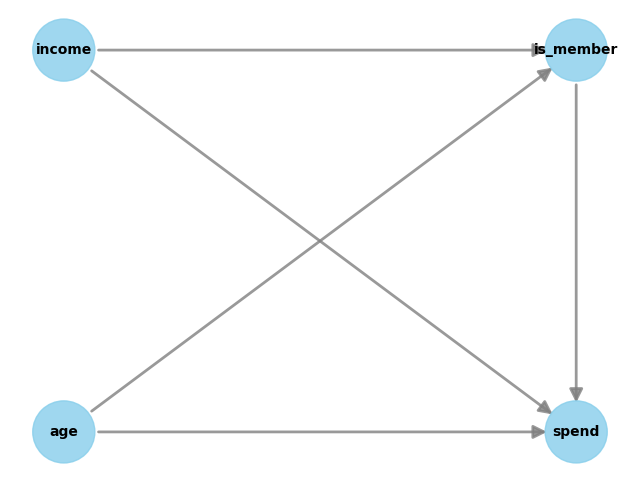

In [3]:
import dowhy
from dowhy import CausalModel

# 1. 定义与绘图 (Define)
# common_causes: 必须包含所有 Confounders (混淆变量)
# instruments: (可选) 如果有工具变量 IV，在此指定
model = CausalModel(
    data=df,
    treatment='is_member',
    outcome='spend',
    common_causes=['income', 'age']
)
model.view_model() 


## 3. Step 2: 识别 (Identify)
让 DoWhy 自动寻找 "如何能够算出来" 的路径 (比如 Backdoor Criterion)。

In [ ]:
# [YOUR CODE HERE]
# identified_estimand = model.identify_effect()
# print(identified_estimand)

In [5]:

# 2. 识别 Estimand (Identify)
# proceed_when_unidentifiable=True: 即使无法完美识别 (e.g. 存在未观测混淆)，也强制继续 (通常用于探索)
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
identified_estimand

## 4. Step 3: 估算 (Estimate)
选择具体的计算方法 (Method)。我们这里试着用 **PSM** 和 **线性回归** 两种方法。
*   Method 1: `backdoor.linear_regression`
*   Method 2: `backdoor.propensity_score_matching`

In [ ]:
# [YOUR CODE HERE]
# estimate = model.estimate_effect(
#     identified_estimand,
#     method_name="backdoor.linear_regression" # 试试换成 propensity_score_matching
# )
# print(f"Causal Estimate is: {estimate.value}")

In [7]:
estimate_lr = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    method_params={
        "d_t": 1, # Treatment 的值
        "d_c": 0, # Control 的值
        "weighting_scheme": "ips_weight" # 仅用于 weighting 方法
    }
)
print(f"Causal Estimate is: {estimate_lr.value}")

Causal Estimate is: 47.3327396190906


In [ ]:

# 3. 估算 (Estimate) - 指定方法
# method_name: 
#   - "backdoor.propensity_score_matching" (PSM)
#   - "backdoor.linear_regression" (简单回归)
#   - "backdoor.propensity_score_weighting" (IPW)
# method_params: 传递给具体底层方法的参数 (e.g. sklearn 模型参数)
estimate_psm = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    method_params={
        "d_t": 1, # Treatment 的值
        "d_c": 0, # Control 的值
        "weighting_scheme": "ips_weight" # 仅用于 weighting 方法
    }
)
print(f"Causal Estimate is: {estimate_psm.value}")

Causal Estimate is: 44.12728448308527


./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [10]:
estimate_ipw = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting", # 这里才用 Weighting
    target_units="ate",
    method_params={"weighting_scheme": "ips_weight"}
)
print(f"Causal Estimate is: {estimate_ipw.value}")

Causal Estimate is: 55.7920523041995


## 5. Step 4: 反驳 (Refute) 🛡️
这是 DoWhy 最强大的功能。如果我给数据加一个随机的干扰项 (Common Cause)，结果应该不变才对。
*   Method: `random_common_cause`

In [8]:
# [YOUR CODE HERE]
refutation = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)
print(refutation)

Refute: Add a random common cause
Estimated effect:44.12728448308527
New effect:44.12728448308527
p value:1.0



In [11]:
# 1. 随机共因 (Random Common Cause)
# 逻辑: 加一个随机干扰项，如果模型稳健，结果不应大变
print(">>> 1. Random Common Cause Check")
refutation_rcc = model.refute_estimate(
    identified_estimand,
    estimate_ipw, # 这里用刚刚算出的 IPW 结果来检验
    method_name="random_common_cause"
)
print(refutation_rcc)

# 2. 安慰剂干预 (Placebo Treatment Refuter)
# 逻辑: 假装发了券 (把 Treatment 随机打乱)，按理说“假券”不该有效果 (Effect 接近 0)
print("\n>>> 2. Placebo Treatment Check")
refutation_placebo = model.refute_estimate(
    identified_estimand,
    estimate_ipw,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(refutation_placebo)

# 3. 数据子集验证 (Data Subset Refuter)
# 逻辑: 随机删掉 20% 数据，看看结果是不是变来变去 (验证稳定性)
print("\n>>> 3. Data Subset Check")
refutation_subset = model.refute_estimate(
    identified_estimand,
    estimate_ipw,
    method_name="data_subset_refuter",
    subset_fraction=0.8
)
print(refutation_subset)


>>> 1. Random Common Cause Check
Refute: Add a random common cause
Estimated effect:55.7920523041995
New effect:55.792052304199494
p value:1.0


>>> 2. Placebo Treatment Check
Refute: Use a Placebo Treatment
Estimated effect:55.7920523041995
New effect:-137.09178533447823
p value:0.0


>>> 3. Data Subset Check
Refute: Use a subset of data
Estimated effect:55.7920523041995
New effect:56.17303935780887
p value:0.96



In [ ]:
# 参考答案区 (Run this if you get stuck)
# model = CausalModel(data=df, treatment='is_member', outcome='spend', common_causes=['income', 'age'])
# identified_estimand = model.identify_effect()
# estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
# print(f"Estimate: {estimate.value}")
# ref = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
# print(ref)